# Demo file: The Black Litterman Model

## Illustrated based on MSCI World Country Index Data

In [8]:
# Standard library imports
import os
import sys

# Third party imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Add the project root directory to Python path
project_root = os.path.dirname(os.path.dirname(os.getcwd()))
src_path = os.path.join(project_root, 'qpmwp-course/src')
sys.path.append(project_root)
sys.path.append(src_path)

# Local modules imports
from helper_functions import load_data_msci
from estimation.covariance import Covariance
from estimation.black_litterman import bl_posterior_mu_sigma       # NEW!
from optimization.optimization import MeanVariance, Objective
from optimization.constraints import Constraints

### Load Data (i.e., return series of MSCI country indices)

In [9]:
data = load_data_msci(path = '../data/')

In [10]:
country_names = [
    'US',
    'JP',
    'GB',
    'CA',
    'FR',
]
cap_weights = pd.Series(
    data=[
        0.7199,   # US
        0.051,    # JP
        0.0378,   # GB
        0.031,    # CA
        0.0288,   # FR
    ],
    index=country_names,
)
# Normalize such that weights sum to one
cap_weights = cap_weights / cap_weights.sum()

cap_weights

US    0.828900
JP    0.058722
GB    0.043523
CA    0.035694
FR    0.033161
dtype: float64

### Compute the market-cap Implied Expected Returns (Prior)

Excess return of mu_implied for US w.r.t. to the average: 0.0242636821029448


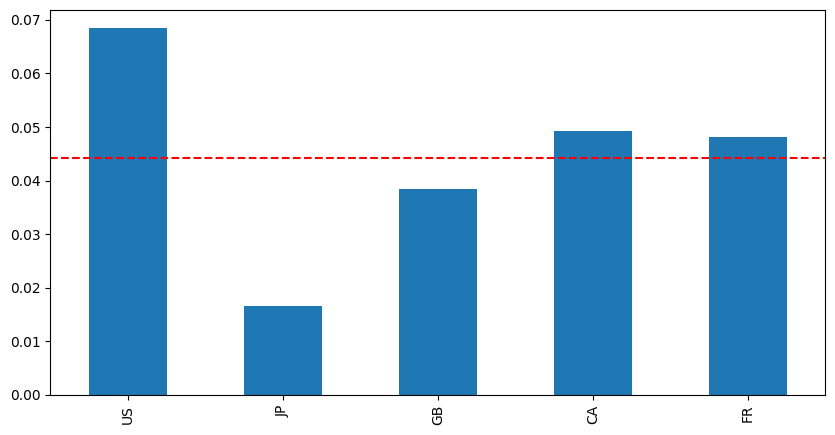

In [11]:
# Step 1: Compute the covariance matrix for the selected country indices
covariance = Covariance(method='pearson')
return_series = data['return_series'][country_names] #.tail(252*3)
covmat = covariance.estimate(return_series, inplace=False) * 252  # Annualize the covariance matrix
covmat

# Step 2. Calculate implied expected return from the cap-weights
risk_aversion = 2
mu_implied = risk_aversion * covmat @ cap_weights

mu_implied.plot(kind='bar', figsize=(10, 5))
plt.axhline(y=mu_implied.mean(), color='r', linestyle='--')

print('Excess return of mu_implied for US w.r.t. to the average:', mu_implied['US'] - mu_implied.mean())

np.float64(2.0747292772682613e-15)

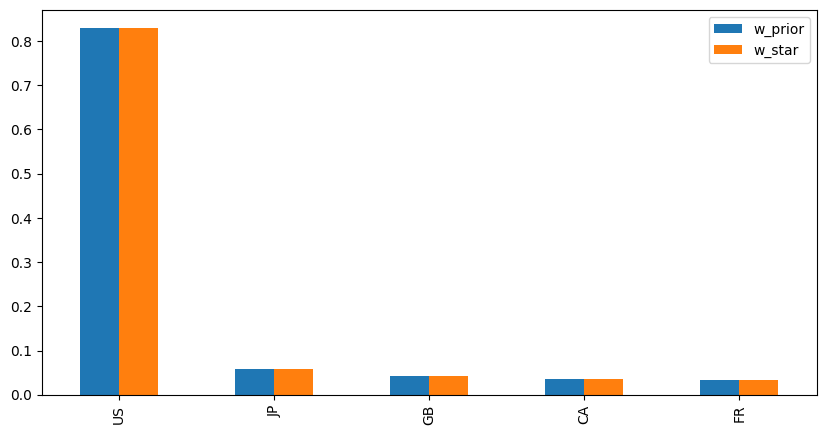

In [12]:
# Step 3: Assert that analytical solution to the unconstrained mean-variance optimization
# using the implied expected returns gives the same weights as the cap-weights
w_star = pd.Series(np.linalg.inv(risk_aversion*covmat) @ mu_implied, index=country_names)

W = pd.DataFrame([cap_weights, w_star], index=["w_prior", "w_star"]).T
W.plot(kind="bar", figsize=(10, 5))
W
np.abs(W['w_star'] - W['w_prior']).sum()

Correlation between modified and original expected returns: 
                mu_implied  mu_implied_mod
mu_implied        1.000000        0.959313
mu_implied_mod    0.959313        1.000000

Correlation between modified and original weights: 
             w_prior    w_star  w_star_mod
w_prior     1.000000  1.000000    0.699406
w_star      1.000000  1.000000    0.699406
w_star_mod  0.699406  0.699406    1.000000



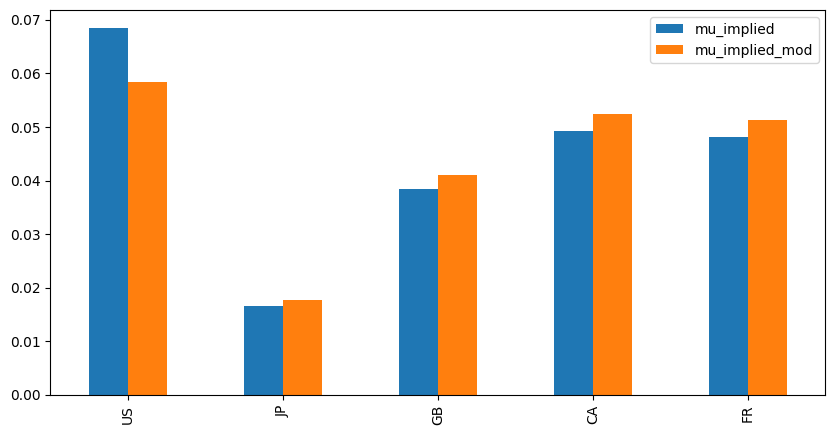

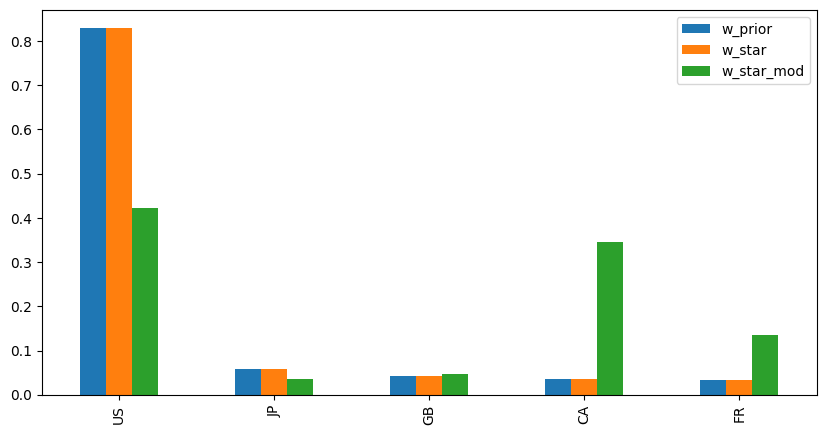

In [13]:
# Step 4: Show input sensitivity of the mean-variance optimization.
# For that, modify the implied expected returns and recompute the optimal weights.
mu_implied_mod = mu_implied.copy()
mu_implied_mod.iloc[0] = mu_implied_mod.iloc[0] * 0.8
mu_implied_mod = mu_implied_mod / mu_implied_mod.sum() * mu_implied.sum()

Mu = pd.concat({
    'mu_implied': mu_implied,
    'mu_implied_mod': mu_implied_mod,
}, axis=1)
Mu.plot(kind='bar', figsize=(10, 5))

# Optimal weights with modified expected returns
w_star_mod = pd.Series(np.linalg.inv(risk_aversion*covmat) @ mu_implied_mod, index=country_names)
W = pd.DataFrame([cap_weights, w_star, w_star_mod], index=["w_prior", "w_star", "w_star_mod"]).T
W.plot(kind="bar", figsize=(10, 5))

print(f'Correlation between modified and original expected returns: \n{Mu.corr()}\n')
print(f'Correlation between modified and original weights: \n{W.corr()}\n')


### Creating Views

Let's assume we have the following views:

- View 1: JP will have an expected return of  4%
- View 2: The US will underperform the average of the other countries by 2%
- View 3: The US will outperform Japan by 1% (Notice that this somewhat contradicts Views 1 and 2)

In [14]:
pick_matrix = pd.DataFrame(
    data=[
        [0, 1, 0, 0, 0],                    # Absolute view on JP
        [1, -0.25, -0.25, -0.25, -0.25],    # Relative view on US vs. others
        [1, -1, 0, 0, 0],                   # Relative view on US vs. JP
    ],
    index=['View1', 'View2', 'View3'],
    columns=country_names,
)

views_vector = pd.Series(
    data=[0.04, -0.02, 0.01],
    index=pick_matrix.index,
)

print(f'Pick matrix (P): \n{pick_matrix}\n')
print(f'Views vector (q): \n{views_vector}\n')

Pick matrix (P): 
       US    JP    GB    CA    FR
View1   0  1.00  0.00  0.00  0.00
View2   1 -0.25 -0.25 -0.25 -0.25
View3   1 -1.00  0.00  0.00  0.00

Views vector (q): 
View1    0.04
View2   -0.02
View3    0.01
dtype: float64



### Posterior Expected Returns

In [15]:
# -------------------------
# Tuning parameters
tau_psi = 0.05
tau_omega = 0.001
# -------------------------

# Uncertainty of the prior
Psi = covmat * tau_psi

# Uncertainty of the views
Omega = pd.DataFrame(
    np.diag([tau_omega] * len(views_vector)),
    index=views_vector.index,
    columns=views_vector.index
)

# # Alternatively:
# Omega = pick_matrix @ covmat @ pick_matrix.T * 100
# Psi = covmat * 0.01

print(f'Uncertainty of the prior (Psi): \n{Psi}\n')
print(f'Uncertainty of the views (Omega): \n{Omega}\n')

Uncertainty of the prior (Psi): 
          US        JP        GB        CA        FR
US  0.001892  0.000280  0.000929  0.001296  0.001177
JP  0.000280  0.002139  0.000539  0.000389  0.000642
GB  0.000929  0.000539  0.001641  0.000881  0.001709
CA  0.001296  0.000389  0.000881  0.001636  0.001058
FR  0.001177  0.000642  0.001709  0.001058  0.002343

Uncertainty of the views (Omega): 
       View1  View2  View3
View1  0.001  0.000  0.000
View2  0.000  0.001  0.000
View3  0.000  0.000  0.001



,mu_prior,mu_posterior
mu_prior,1.000000,0.604318
mu_posterior,0.604318,1.000000


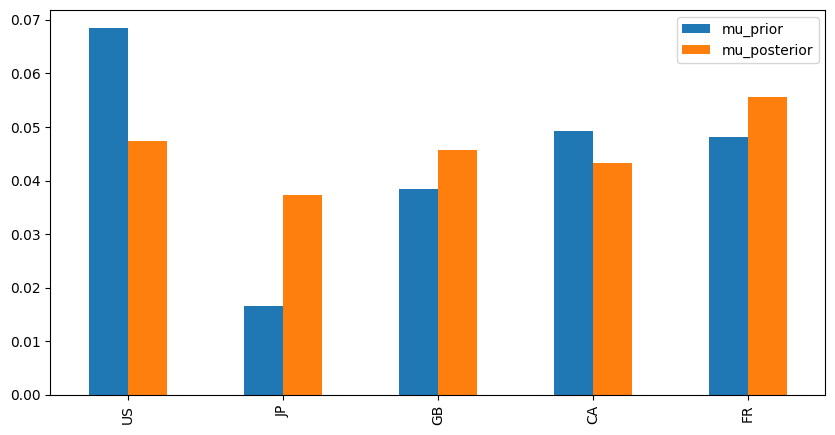

In [17]:
# Compute the posterior expected return vector and covariance matrix
mu_posterior, sigma_posterior = bl_posterior_mu_sigma(
    mu_prior=mu_implied,
    covmat=covmat, 
    P=pick_matrix,
    q=views_vector,
    Psi=Psi,
    Omega=Omega,
    # confidence=1,
)

Mu = pd.concat({
    "mu_prior": mu_implied,
    "mu_posterior": mu_posterior,
}, axis=1)

Mu
Mu.plot(kind="bar", figsize=(10, 5))
Mu.corr()

### Portfolio Optimization

,w_prior,w_star_posterior
US,0.828900,0.272955
JP,0.058722,0.271068
GB,0.043523,0.181122
CA,0.035694,0.173292
FR,0.033161,0.170759


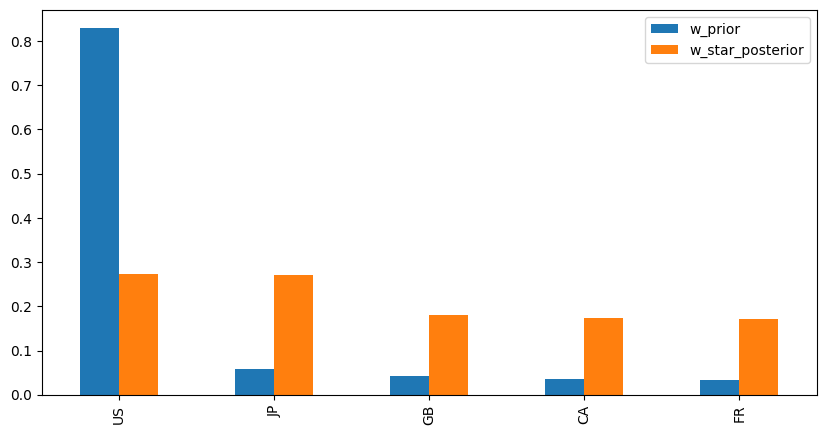

In [20]:
# Analytical mean-variance optimization with the posterior returns
w_star_post = pd.Series(np.linalg.inv(risk_aversion*covmat) @ mu_posterior, index=country_names)
W = pd.DataFrame([cap_weights, w_star_post], index=["w_prior", "w_star_posterior"]).T
W.plot(kind="bar", figsize=(10, 5))
W

w_prior                        1.000000
w_star_posterior_analytical    1.069197
w_star_posterior_numerical     1.069197
dtype: float64

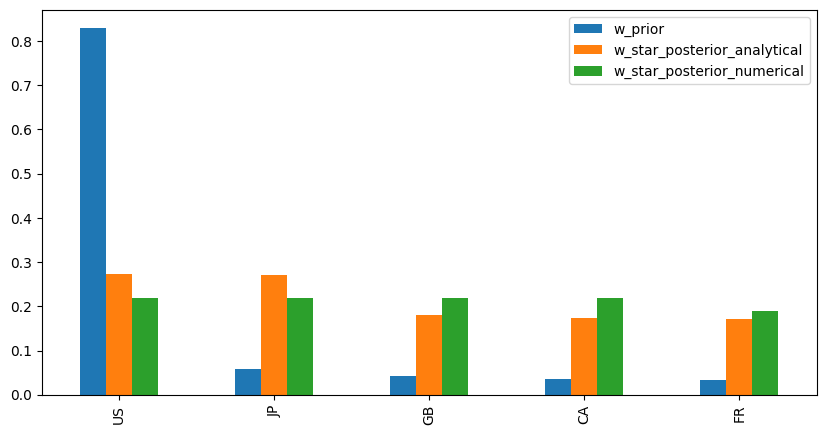

In [22]:
# Re-run the mean-variance optimization, using a solver, with the posterior returns

constraints = Constraints(country_names)
# constraints.add_budget()
# constraints.add_box(lower=0, upper=0.3)
constraints.add_budget(rhs=w_star_post.sum()) # Use the sum of the analytical posterior weights as the budget constraint for comparability
constraints.add_box(lower=0, upper=0.22)

mv = MeanVariance(
    constraints=constraints,
    solver_name="cvxopt",
)
mv.objective = Objective(
    q=mu_posterior*(-1),
    P=2*covmat, # Uses the original covariance matrix, ignoring the uncertainty in the expected returns
)

# # Alternatively, 
# mv.objective = Objective(
#     q=mu_posterior*(-1),
#     P=2*(covmat + sigma_posterior),  # Add the posterior covariance to the original covariance to account for the uncertainty in the expected returns
# )

mv.solve()
w_posterior = pd.Series(mv.results["weights"])

W = pd.DataFrame([cap_weights, w_star_post, w_posterior],
                 index=["w_prior", "w_star_posterior_analytical", "w_star_posterior_numerical"]).T
W.plot(kind="bar", figsize=(10, 5))
W.sum()

# data['return_series'][country_names].corr()   # Notice the correlation between US and CA